# Synthetic Data untuk Keamanan Data

Notebook ini mendemonstrasikan pembuatan **data sintetis** berbasis _Conditional Tabular GAN_ (CTGAN)
menggunakan dataset Adult Income (UCI) yang diadaptasi menjadi data demografis Indonesia.


| Info | Detail |
|---|---|
| **Dataset** | UCI Adult Income (48.842 baris, 15 kolom) |
| **Model Generatif** | CTGAN (SDV Library) |
| **Output** | 1.500 baris data sintetis berkualitas tinggi |
| **Evaluasi** | TSTR — akurasi model sintetis vs baseline |


## **Bagian 1: Library**


In [1]:
!pip install sdv faker pandas xgboost lightgbm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.5 MB/s eta 0:00:00


In [2]:
# Manipulasi Data
import pandas as pd
import numpy as np
import random

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Generatif (SDV / CTGAN)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, accuracy_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


## **Bagian 2: Load Dataset**

Dataset yang digunakan adalah **UCI Adult Income**, yaitu dataset klasifikasi yang berisi data demografis
dan ekonomi penduduk Amerika Serikat. Target variabelnya adalah `income` (≤50K atau >50K per tahun).


In [3]:
# Load dataset dan tampilkan info dasar
df_real = pd.read_csv('adult.csv')

print(f'Shape    : {df_real.shape}')
print(f'Kolom    : {list(df_real.columns)}')
print(f'Missing  : {df_real.isnull().sum().sum()} nilai')
print()
df_real.info()

Shape    : (48842, 15)
Kolom    : ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Missing  : 0 nilai

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 


In [4]:
# Tampilkan 5 baris pertama untuk inspeksi awal
df_real.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
# Distribusi target variable
print('Distribusi kelas target (income):')
print(df_real['income'].value_counts())
print()
print(df_real['income'].value_counts(normalize=True).map(lambda x: f'{x:.1%}'))

Distribusi kelas target (income):
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

income
<=50K    76.1%
>50K     23.9%
Name: proportion, dtype: object


## **Bagian 3: Prototype: CTGAN + Augmentasi Identitas Indonesia**

Eksplorasi awal untuk memvalidasi pipeline sebelum optimasi penuh dilakukan.

Pipeline terdiri dari 4 fase:
1. Training CTGAN ringan (`epochs=30`) pada subset kolom
2. Generate pola anonim
3. Injeksi identitas Indonesia (Nama per suku, NIK, Alamat)
4. Simpan hasil

> Hasil di bagian ini **belum digunakan untuk evaluasi akhir**[link text](https://)


### Konfigurasi Identitas Indonesia

Pool nama dikelompokkan per **suku** dan **jenis kelamin**, mencakup 10 suku utama Indonesia.
Distribusi suku mengikuti proporsi populasi nyata.


In [6]:
# Distribusi suku
SUKU_LIST    = ['Jawa', 'Sunda', 'Batak', 'Madura', 'Betawi',
                'Minangkabau', 'Bugis', 'Melayu', 'Bali', 'Tionghoa']
SUKU_WEIGHTS = [0.40, 0.15, 0.04, 0.03, 0.03, 0.03, 0.03, 0.04, 0.02, 0.02]

# Pool nama per suku
NAME_POOLS = {
    'Jawa': {
        'male_first'  : ['Budi','Agus','Eko','Joko','Slamet','Sutrisno','Wahyu','Bayu','Dimas','Rizky','Satria','Hadi','Tri','Dwi','Bagus'],
        'female_first': ['Siti','Sri','Dewi','Rini','Lestari','Wulan','Ayu','Indah','Tari','Rahayu','Ratna','Putri','Sari'],
        'last'        : ['Santoso','Wibowo','Prasetyo','Haryanto','Nugroho','Widodo','Wijaya','Saputra','Prabowo','Kusuma']
    },
    'Sunda': {
        'male_first'  : ['Asep','Ujang','Dadan','Usep','Cecep','Rizal','Didin','Agung','Yayan','Dedi'],
        'female_first': ['Euis','Tati','Neng','Iis','Sari','Dewi','Sinta','Rina','Nia','Lia'],
        'last'        : ['Saputra','Suryana','Gunawan','Kusnadi','Kurniawan','Rosadi','Herlambang','Purnama','Permana']
    },
    'Batak': {
        'male_first'  : ['Raja','Togar','Hotman','Jannes','Binsar','Tumpal','Saut','Domu','Martua'],
        'female_first': ['Tiur','Risma','Meylani','Sorta','Lina','Riani','Dorce','Nova'],
        'last'        : ['Siregar','Simanjuntak','Nasution','Harahap','Panjaitan','Manurung','Sinaga','Nainggolan','Hasibuan','Gultom','Lubis']
    },
    'Madura': {
        'male_first'  : ['Samsul','Mahfud','Husen','Fauzi','Taufik','Rasyid','Basri','Zainal'],
        'female_first': ['Nurul','Sulastri','Aminah','Kholifah','Faridah','Siti'],
        'last'        : ['Zaini','Fauzan','Basri','Hasyim','Halim','Rahman']
    },
    'Betawi': {
        'male_first'  : ['Udin','Rojali','Mamat','Babeh','Soleh','Jali','Burhan','Ridwan'],
        'female_first': ['Eneng','Mpok','Fatimah','Rohayah','Nuraini','Salmah','Maryam'],
        'last'        : ['Fachruddin','Abdurrahman','Iskandar','Maulana','Syafei','Rahman']
    },
    'Minangkabau': {
        'male_first'  : ['Fahri','Rangga','Indra','Yandri','Zulkifli','Reyhan','Ardi'],
        'female_first': ['Asni','Rizka','Suci','Nadya','Rani','Salsabila'],
        'last'        : ['Chaniago','Piliang','Koto','Sikumbang','Lubuk','Batuah','Payobada']
    },
    'Bugis': {
        'male_first'  : ['Andi','Basri','Fadli','Syamsul','Herman','Rahmat','Ilham'],
        'female_first': ['Andi','Nur','Fitri','Aldira','Rahma','Dahlia'],
        'last'        : ['Mappangara','Massappa','Tenriola','Mallongi','Daeng','Pattola']
    },
    'Melayu': {
        'male_first'  : ['Syahrul','Rafi','Fikri','Rahman','Hafiz','Iqbal','Zainuddin'],
        'female_first': ['Nuraini','Aisyah','Zahra','Nabila','Salsabila','Rania'],
        'last'        : ['Ismail','Rahman','Aziz','Yusuf','Hassan','Mahmud']
    },
    'Bali': {
        'male_first'  : ['Wayan','Made','Nyoman','Ketut','Gede','Komang'],
        'female_first': ['Ni Wayan','Ni Made','Ni Nyoman','Ni Ketut','Ayu','Kadek'],
        'last'        : ['Putra','Adnyana','Arimbawa','Saputra','Mahendra','Suartana']
    },
    'Tionghoa': {
        'male_first'  : ['Hendra','Eddy','Benny','Tony','Kevin','Jason','William','Andrew'],
        'female_first': ['Lia','Cindy','Jessica','Wendy','Irene','Olivia','Tina','Susi'],
        'last'        : ['Tan','Lim','Huang','Tjoa','Lie','Oei','Wijaya','Gunawan']
    }
}

DEFAULT_POOL = {
    'male_first'  : ['Rizky','Dimas','Andi','Agus'],
    'female_first': ['Ayu','Siti','Dewi','Rina'],
    'last'        : ['Saputra','Pratama','Wijaya','Santoso']
}

MIDDLE_POOL = ['Adi','Nur','Putra','Putri','Ayu','Tri','Dwi','Mega','Ananda','Cahya','Intan','Kirana']
SUFFIX_POOL = ['', '', '', 'S.H.', 'S.Kom.', 'S.T.', 'M.Kom.', 'M.T.']
CITIES      = ['Jakarta','Bandung','Surabaya','Medan','Semarang','Yogyakarta','Makassar','Denpasar']
STREETS     = ['Jl. Sudirman','Jl. Merdeka','Jl. Gatot Subroto','Jl. Ahmad Yani','Jl. Diponegoro']

print('Konfigurasi identitas Indonesia siap.')

Konfigurasi identitas Indonesia siap.


### Fungsi Generator Identitas

**Format NIK (16 digit):**
```
[kode_prov: 2] [kode_kota: 4] [tgl_lahir: 6] [nomor_urut: 4]
```
Khusus perempuan, hari lahir ditambah **40** sesuai konvensi Dukcapil RI.


In [7]:
# Pelacak nama yang sudah digunakan agar setiap identitas unik
_used_names = set()


def build_name(suku, sex):
    pool  = NAME_POOLS.get(suku, DEFAULT_POOL)
    first = random.choice(pool['male_first'] if sex.lower() == 'male' else pool['female_first'])
    last  = random.choice(pool['last'])
    # 35% kemungkinan nama tengah
    full  = f'{first} {random.choice(MIDDLE_POOL)} {last}' if random.random() < 0.35 else f'{first} {last}'
    # 15% kemungkinan gelar akademik
    suffix = random.choice(SUFFIX_POOL)
    return f'{full}, {suffix}' if suffix else full


def generate_unique_name(suku, sex):
    # Retry hingga mendapatkan nama yang belum pernah digunakan
    while True:
        name = build_name(suku, sex)
        if name not in _used_names:
            _used_names.add(name)
            return name


def generate_nik(age, sex):
    prov        = random.choice(['31','32','33','34','35','12','13','51'])
    kota        = f'{random.randint(1000, 9999)}'
    tahun_lahir = 2025 - int(age)
    bulan       = random.randint(1, 12)
    hari        = random.randint(1, 28)
    if sex.strip().lower() == 'female':
        hari += 40  # Konvensi Dukcapil untuk perempuan
    tgl_str = f'{hari:02}{bulan:02}{str(tahun_lahir)[-2:]}'
    serial  = f'{random.randint(1, 9999):04}'
    return f'{prov}{kota}{tgl_str}{serial}'


def generate_address():
    return f'{random.choice(STREETS)} No. {random.randint(1, 200)}, {random.choice(CITIES)}'


def augment_with_indonesian_identity(df, sex_col='sex'):
    # Tentukan suku untuk setiap baris
    df = df.copy()
    suku_list = random.choices(SUKU_LIST, weights=SUKU_WEIGHTS, k=len(df))

    names, niks, addresses = [], [], []
    for (_, row), suku in zip(df.iterrows(), suku_list):
        sex = str(row.get(sex_col, 'male'))
        names.append(generate_unique_name(suku, sex))
        niks.append(generate_nik(row['age'], sex))
        addresses.append(generate_address())

    # Ganti kolom ras dengan kolom Suku Indonesia
    if 'race' in df.columns:
        df['race'] = suku_list
        df.rename(columns={'race': 'Suku'}, inplace=True)

    df.insert(0, 'Name',     names)
    df.insert(1, 'ID (NIK)', niks)
    df['Address'] = addresses
    return df

print('Fungsi generator identitas siap.')

Fungsi generator identitas siap.


### Training CTGAN Prototype

Training singkat (`epochs=30`) untuk memvalidasi pipeline. Menggunakan subset 8 kolom.


In [9]:
PROTO_COLS = ['age', 'workclass', 'education', 'marital-status',
              'occupation', 'race', 'gender', 'income']

proto_train = df_real[PROTO_COLS].copy()

proto_meta = SingleTableMetadata()
proto_meta.detect_from_dataframe(proto_train)

proto_synthesizer = CTGANSynthesizer(proto_meta, epochs=30, verbose=True)
proto_synthesizer.fit(proto_train)
print('\nTraining prototype selesai.')

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-00.43) | Discrim. (-00.22): 100%|██████████| 30/30 [01:14<00:00,  2.50s/it]


Training prototype selesai.


### Generate & Augmentasi Data Prototype

In [12]:
# Generate 1.500 baris pola anonim
df_proto_raw = proto_synthesizer.sample(num_rows=1500)
print(f'Data ter-generate: {df_proto_raw.shape}')

# Augmentasi identitas Indonesia
df_proto = augment_with_indonesian_identity(df_proto_raw, sex_col='gender')

# Tampilkan sampel
preview_cols = ['Name', 'ID (NIK)', 'age', 'Suku', 'education', 'occupation', 'gender', 'Address', 'income']
print('\nSampel data prototype (5 baris):')
display(df_proto[preview_cols].head())

df_proto.to_csv('synthetic_data_prototype.csv', index=False)
print('\nDisimpan ke: synthetic_data_prototype.csv')

Data ter-generate: (1500, 8)

Sampel data prototype (5 baris):


,Name,ID (NIK),age,Suku,education,occupation,gender,Address,income
0,"Bayu Putra Prasetyo, S.T.",1350871601862212,39,Jawa,HS-grad,Transport-moving,Male,"Jl. Diponegoro No. 113, Yogyakarta",<=50K
1,"Ujang Permana, M.Kom.",1220000810541455,71,Sunda,HS-grad,Priv-house-serv,Male,"Jl. Merdeka No. 184, Medan",<=50K
2,Nuraini Aziz,3282945607757535,50,Melayu,Prof-school,Prof-specialty,Female,"Jl. Sudirman No. 98, Makassar",>50K
3,"Hadi Wibowo, S.T.",3352502612691628,56,Jawa,Bachelors,Protective-serv,Male,"Jl. Gatot Subroto No. 121, Jakarta",>50K
4,"Ayu Ayu Widodo, M.T.",3157985802835262,42,Jawa,Assoc-acdm,Exec-managerial,Female,"Jl. Gatot Subroto No. 194, Semarang",<=50K



Disimpan ke: synthetic_data_prototype.csv


## **Bagian 4: Refinement: CTGAN Optimal**

Pelatihan CTGAN yang lebih serius dengan hyperparameter dioptimalkan untuk hasil _high fidelity_.

| Parameter | Prototype | Refinement |
|---|---|---|
| `epochs` | 30 | **500** |
| `batch_size` | default | **500** |
| `generator_dim` | default | **(256, 256, 256)** |
| `discriminator_dim` | default | **(256, 256, 256)** |
| Jumlah kolom | 8 | **14** |

> Estimasi waktu training: **~25–30 menit** di GPU T4.


### Seleksi Kolom & Deteksi Metadata

In [13]:
# Semua kolom yang tidak mengandung PII langsung
SELECTED_COLS = [
    'age', 'workclass', 'education', 'educational-num', 'marital-status',
    'occupation', 'relationship', 'race', 'gender',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

data_train = df_real[SELECTED_COLS].copy()
print(f'Data training: {data_train.shape[0]} baris, {data_train.shape[1]} kolom')

# Auto-detect tipe setiap kolom
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data_train)

print('\nMetadata terdeteksi:')
for col, info in metadata.to_dict()['columns'].items():
    print(f'  {col:<20} → {info["sdtype"]}')

Data training: 48842 baris, 14 kolom

Metadata terdeteksi:
  age                  → numerical
  workclass            → categorical
  education            → categorical
  educational-num      → numerical
  marital-status       → categorical
  occupation           → categorical
  relationship         → categorical
  race                 → categorical
  gender               → categorical
  capital-gain         → numerical
  capital-loss         → numerical
  hours-per-week       → numerical
  native-country       → categorical
  income               → categorical


### Konfigurasi & Training CTGAN

In [14]:
synthesizer = CTGANSynthesizer(
    metadata,
    enforce_rounding=False,             # Angka desimal lebih presisi
    epochs=500,                         # Cukup untuk konvergensi
    batch_size=500,                     # Stabilisasi pembaruan bobot
    generator_dim=(256, 256, 256),      # Generator: 3 layer × 256 neuron
    discriminator_dim=(256, 256, 256),  # Discriminator: 3 layer × 256 neuron
    verbose=True
)

print('>>> Mulai training CTGAN... (estimasi ~25-30 menit di GPU T4)')
synthesizer.fit(data_train)
print('\nTraining selesai!')

>>> Mulai training CTGAN... (estimasi ~25-30 menit di GPU T4)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-01.17) | Discrim. (+00.23): 100%|██████████| 500/500 [26:21<00:00,  3.16s/it]


Training selesai!


### Generate Data Sintetis

In [15]:
NUM_SAMPLES   = 1500
synthetic_data = synthesizer.sample(num_rows=NUM_SAMPLES)

print(f'Data ter-generate : {synthetic_data.shape}')
display(synthetic_data.head())

Data ter-generate : (1500, 14)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,28,Private,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,Amer-Indian-Eskimo,Male,0,0,49,United-States,<=50K
1,30,Federal-gov,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,7,0,40,United-States,<=50K
2,38,Private,Doctorate,16,Divorced,Prof-specialty,Unmarried,White,Male,1,0,49,United-States,>50K
3,33,Self-emp-not-inc,HS-grad,9,Never-married,Other-service,Own-child,White,Female,17,0,35,United-States,<=50K
4,33,?,Some-college,10,Married-civ-spouse,?,Wife,White,Female,11,0,40,United-States,<=50K


## **Bagian 5: Post-Processing**

CTGAN kadang menghasilkan nilai desimal atau negatif pada kolom numerik.
Tahap ini memastikan semua nilai berada dalam rentang yang realistis.

| Kolom | Perlakuan |
|---|---|
| `age` | Clip minimum **17** (usia kerja), konversi ke integer |
| `capital-gain` | Clip minimum **0**, konversi ke integer |
| `capital-loss` | Clip minimum **0**, konversi ke integer |
| `hours-per-week` | Clip minimum **0**, konversi ke integer |


In [16]:
NUMERIC_COLS = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
CLIP_MIN     = {'age': 17}  # batas bawah khusus

for col in NUMERIC_COLS:
    if col not in synthetic_data.columns:
        continue
    synthetic_data[col] = pd.to_numeric(synthetic_data[col], errors='coerce')
    synthetic_data[col] = synthetic_data[col].fillna(0)
    lower = CLIP_MIN.get(col, 0)
    synthetic_data[col] = synthetic_data[col].clip(lower=lower).astype(int)

print('Post-processing selesai.')
print()
print('Statistik kolom numerik setelah post-processing:')
display(synthetic_data[NUMERIC_COLS].describe().round(1))

Post-processing selesai.

Statistik kolom numerik setelah post-processing:


,age,capital-gain,capital-loss,hours-per-week
count,1500.0,1500.0,1500.0,1500.0
mean,41.0,340.2,32.4,40.9
std,14.3,3879.9,244.1,11.4
min,17.0,0.0,0.0,4.0
25%,28.0,0.0,0.0,40.0
50%,40.0,4.0,0.0,40.0
75%,52.0,11.0,0.0,46.0
max,80.0,99999.0,2058.0,88.0


In [17]:
OUTPUT_FILE = 'synthetic_data_refined.csv'
synthetic_data.to_csv(OUTPUT_FILE, index=False)
print(f'Data disimpan ke: {OUTPUT_FILE}')

Data disimpan ke: synthetic_data_refined.csv


## **6. EDA: Perbandingan Distribusi Data Asli vs Sintetis**

Dua analisis dilakukan untuk memverifikasi kualitas data sintetis:
1. **Distribusi fitur** — perbandingan visual per kolom
2. **Ethics check** — deteksi bias gender


### Fungsi Visualisasi Perbandingan

In [18]:
def plot_comparison(real, synthetic, columns, title=''):
    # Numerik  : KDE plot
    # Kategorikal : Bar chart proporsi (Top 5 kategori)
    n_cols = 3
    n_rows = -(-len(columns) // n_cols)  # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]
        if real[col].dtype in ['int64', 'float64']:
            sns.kdeplot(real[col],      ax=ax, label='Real',      fill=True, color='steelblue', alpha=0.4)
            sns.kdeplot(synthetic[col], ax=ax, label='Synthetic', fill=True, color='seagreen',  alpha=0.4)
        else:
            top_cats = real[col].value_counts().index[:5]
            r_prop   = real[col].value_counts(normalize=True).reindex(top_cats, fill_value=0)
            s_prop   = synthetic[col].value_counts(normalize=True).reindex(top_cats, fill_value=0)
            df_bar   = pd.DataFrame({'Real': r_prop.values, 'Synthetic': s_prop.values}, index=top_cats)
            df_bar.plot(kind='bar', ax=ax, color=['steelblue','seagreen'], alpha=0.75, rot=30)

        ax.set_title(f'Distribusi: {col}', fontsize=11)
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


print('Fungsi plot_comparison siap.')

Fungsi plot_comparison siap.


### Perbandingan Distribusi Kolom Kunci

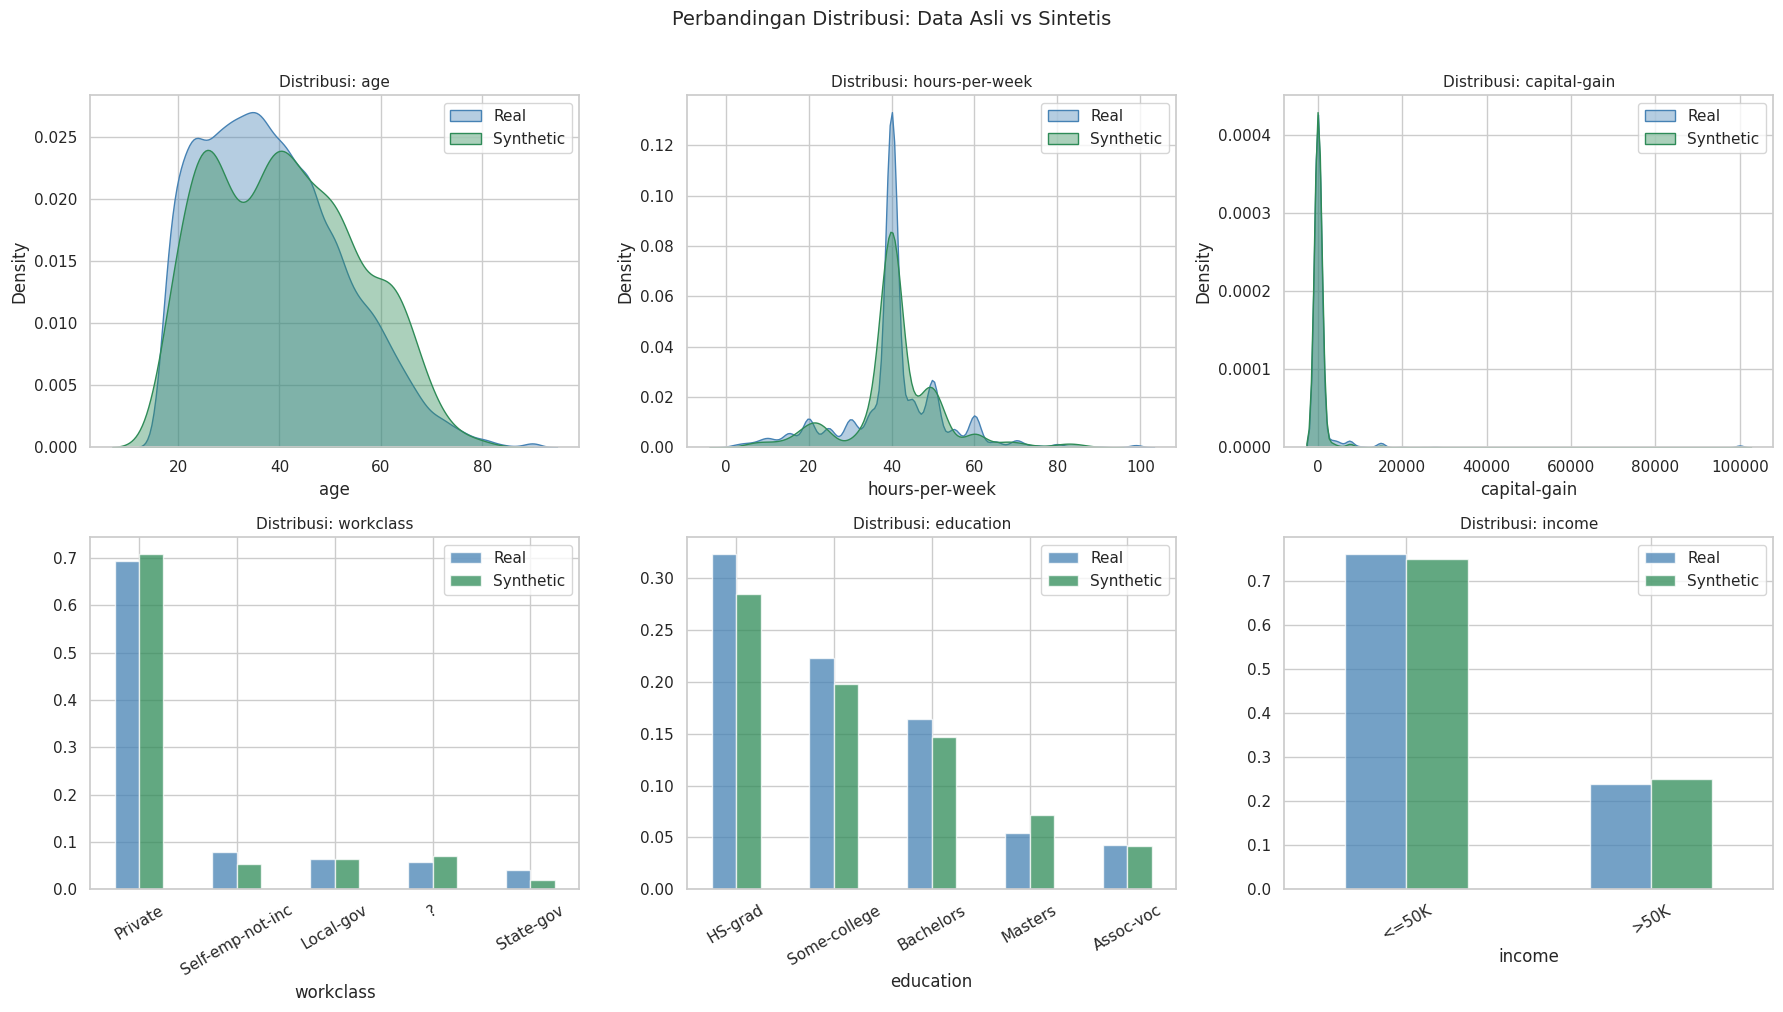

In [19]:
key_columns = ['age', 'hours-per-week', 'capital-gain', 'workclass', 'education', 'income']

plot_comparison(
    df_real[SELECTED_COLS],
    synthetic_data,
    key_columns,
    title='Perbandingan Distribusi: Data Asli vs Sintetis'
)

### Ethics Check untuk Analisis Gender Bias

Diukur apakah **proporsi pendapatan tinggi (>50K) per gender** di data sintetis
mencerminkan data asli, atau justru memperparah ketimpangan yang sudah ada.

- Gap sintetis ≈ gap asli → tidak ada bias tambahan
- Gap sintetis >> gap asli → model memperparah bias gender


In [20]:
def check_gender_bias(df, label, gender_col='gender'):
    ratio = df.groupby(gender_col)['income'].apply(lambda x: (x.str.strip() == '>50K').mean())
    gap   = ratio.max() - ratio.min()
    print(f'── {label} ──')
    print(ratio.to_string())
    print(f'Gap (Male - Female): {gap:.4f}\n')
    return ratio


bias_real = check_gender_bias(df_real, 'Data Asli', gender_col='gender')
bias_syn  = check_gender_bias(synthetic_data, 'Data Sintetis', gender_col='gender')

── Data Asli ──
gender
Female    0.109251
Male      0.303767
Gap (Male - Female): 0.1945

── Data Sintetis ──
gender
Female    0.143541
Male      0.325315
Gap (Male - Female): 0.1818



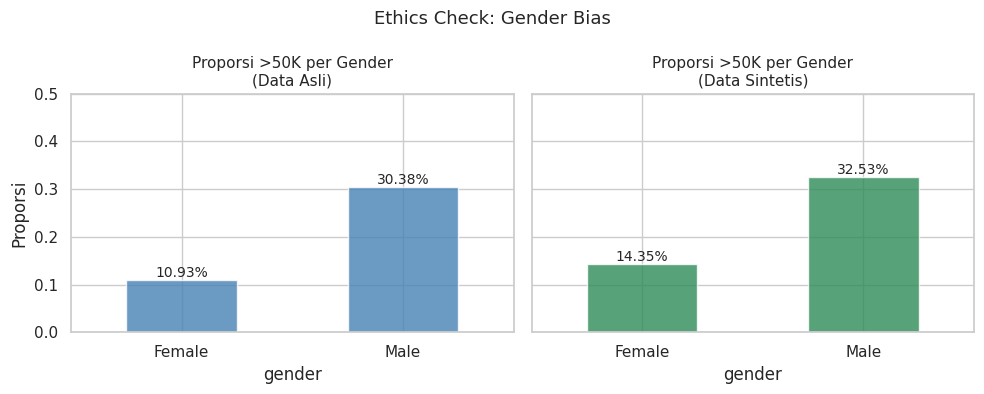

In [21]:
# Visualisasi perbandingan bias gender
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, (ratio, label, color) in zip(axes, [
    (bias_real, 'Data Asli',     'steelblue'),
    (bias_syn,  'Data Sintetis', 'seagreen')
]):
    ratio.plot(kind='bar', ax=ax, color=color, alpha=0.8, rot=0)
    ax.set_title(f'Proporsi >50K per Gender\n({label})', fontsize=11)
    ax.set_ylabel('Proporsi')
    ax.set_ylim(0, 0.5)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Ethics Check: Gender Bias', fontsize=13)
plt.tight_layout()
plt.show()

## **Bagian 7: Evaluasi Model ML Metode TSTR**

**TSTR (Train on Synthetic, Test on Real)** adalah standar evaluasi kualitas data sintetis:

```
Model Baseline : dilatih pada data ASLI     → diuji pada data ASLI  (benchmark)
Model TSTR     : dilatih pada data SINTETIS → diuji pada data ASLI  (eksperimen)
```

Jika performa model TSTR mendekati baseline → data sintetis dianggap **berkualitas tinggi**.

**Threshold kualitas:**

| Penurunan Akurasi | Rating |
|---|---|
| < 5% | Sangat Baik (High Utility) |
| 5%–10% | Cukup Baik (Good Utility) |
| > 10% | Kurang Baik (Low Utility) |


### Preprocessing (Konsisten antara Data Asli & Sintetis)

Kedua dataset digabungkan terlebih dahulu, di-encode bersama, lalu dipisahkan kembali.
Ini memastikan **representasi fitur yang identik** di kedua model.


In [22]:
def preprocess_for_ml(df_real, df_syn, selected_cols, target_col='income'):
    # Beri penanda asal data
    real_cp          = df_real[selected_cols].copy()
    real_cp['_src']  = 'real'
    syn_cp           = df_syn[selected_cols].copy()
    syn_cp['_src']   = 'synthetic'

    combined = pd.concat([real_cp, syn_cp], axis=0, ignore_index=True)

    # Label Encoding untuk semua kolom kategorikal (kecuali penanda & target)
    for col in combined.columns:
        if combined[col].dtype == 'object' and col not in ('_src', target_col):
            le = LabelEncoder()
            combined[col] = le.fit_transform(combined[col].astype(str))

    # Encode target
    le_target        = LabelEncoder()
    combined[target_col] = le_target.fit_transform(combined[target_col].astype(str))

    real_enc = combined[combined['_src'] == 'real'].drop('_src', axis=1)
    syn_enc  = combined[combined['_src'] == 'synthetic'].drop('_src', axis=1)

    X_real = real_enc.drop(target_col, axis=1)
    y_real = real_enc[target_col]
    X_syn  = syn_enc.drop(target_col, axis=1)
    y_syn  = syn_enc[target_col]

    print(f'Fitur    : {X_real.shape[1]} kolom')
    print(f'Real     : {X_real.shape[0]} baris')
    print(f'Sintetis : {X_syn.shape[0]} baris')
    return X_real, y_real, X_syn, y_syn


X_real, y_real, X_syn, y_syn = preprocess_for_ml(df_real, synthetic_data, SELECTED_COLS)

# Split data asli: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)
print(f'\nTest set: {len(X_test)} baris (selalu dari data ASLI)')

Fitur    : 13 kolom
Real     : 48842 baris
Sintetis : 1500 baris

Test set: 9769 baris (selalu dari data ASLI)


### Evaluasi Multi-Model (F1-Score)

Enam model klasifikasi diuji sekaligus untuk mendapatkan gambaran perbandingan yang lebih komprehensif.


Model                    F1 Real    F1 Syn      Drop
----------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression       0.8017    0.8195   -0.0179
Decision Tree             0.8485    0.8226   +0.0259
Random Forest             0.8525    0.8225   +0.0299
Gradient Boosting         0.8566    0.8235   +0.0331


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost                   0.8751    0.8171   +0.0579
LightGBM                  0.8765    0.8228   +0.0536


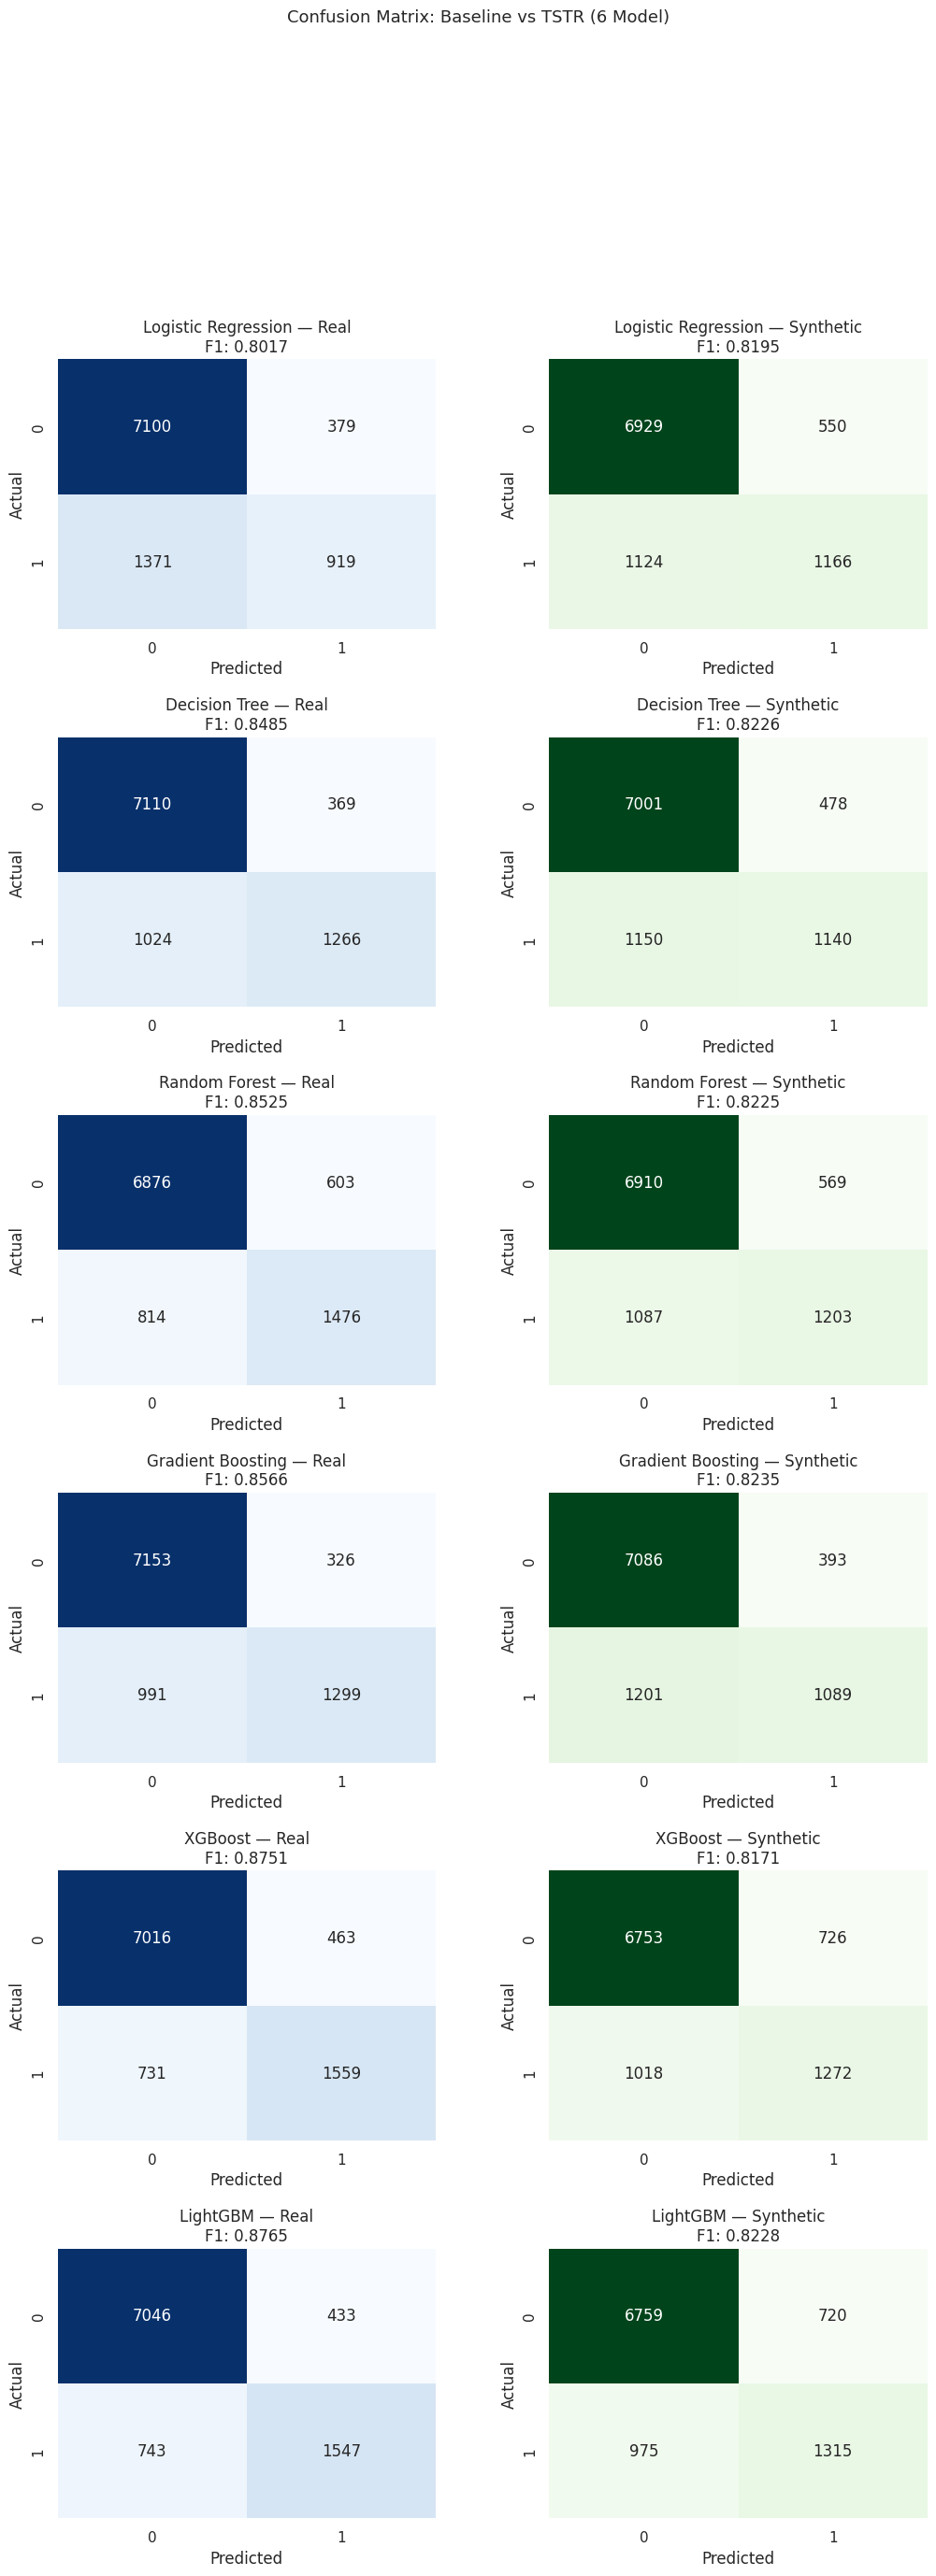

In [23]:
def run_multi_model_tstr(X_train_r, y_train_r, X_syn, y_syn, X_test, y_test):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Decision Tree'      : DecisionTreeClassifier(max_depth=5),
        'Random Forest'      : RandomForestClassifier(n_estimators=50, random_state=42),
        'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=50, random_state=42),
        'XGBoost'            : XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
        'LightGBM'           : LGBMClassifier(verbose=-1, random_state=42)
    }

    n = len(models)
    fig, axes = plt.subplots(n, 2, figsize=(12, 5 * n))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    results = []
    print(f'{"Model":<22}  {"F1 Real":>8}  {"F1 Syn":>8}  {"Drop":>8}')
    print('-' * 52)

    for i, (name, model) in enumerate(models.items()):
        # Baseline: latih pada data asli
        model.fit(X_train_r, y_train_r)
        pred_r = model.predict(X_test)
        f1_r   = f1_score(y_test, pred_r, average='weighted')

        # TSTR: latih pada data sintetis
        model_s = type(model)(**model.get_params())
        model_s.fit(X_syn, y_syn)
        pred_s = model_s.predict(X_test)
        f1_s   = f1_score(y_test, pred_s, average='weighted')

        results.append({'Model': name, 'Type': 'Real (Baseline)',   'F1-Score': round(f1_r, 4)})
        results.append({'Model': name, 'Type': 'Synthetic (TSTR)', 'F1-Score': round(f1_s, 4)})
        print(f'{name:<22}  {f1_r:>8.4f}  {f1_s:>8.4f}  {f1_r - f1_s:>+8.4f}')

        # Confusion matrix
        for j, (pred, lbl, cmap, f1) in enumerate([
            (pred_r, f'{name} — Real',      'Blues',  f1_r),
            (pred_s, f'{name} — Synthetic', 'Greens', f1_s)
        ]):
            cm = confusion_matrix(y_test, pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i, j], cbar=False)
            axes[i, j].set_title(f'{lbl}\nF1: {f1:.4f}')
            axes[i, j].set_xlabel('Predicted'); axes[i, j].set_ylabel('Actual')

    plt.suptitle('Confusion Matrix: Baseline vs TSTR (6 Model)', fontsize=13, y=1.005)
    plt.show()
    return pd.DataFrame(results)


df_f1 = run_multi_model_tstr(X_train, y_train, X_syn, y_syn, X_test, y_test)

In [24]:
# Ringkasan F1-Score dalam format pivot
pivot = df_f1.pivot(index='Model', columns='Type', values='F1-Score')
pivot['Drop'] = (pivot['Real (Baseline)'] - pivot['Synthetic (TSTR)']).round(4)
pivot = pivot.sort_values('Drop')
display(pivot)

Type,Real (Baseline),Synthetic (TSTR),Drop
Model,,,
Logistic Regression,0.8017,0.8195,-0.0178
Decision Tree,0.8485,0.8226,0.0259
Random Forest,0.8525,0.8225,0.0300
Gradient Boosting,0.8566,0.8235,0.0331
LightGBM,0.8765,0.8228,0.0537
XGBoost,0.8751,0.8171,0.0580


### Evaluasi Mendalam: Random Forest + Hyperparameter Tuning

Perbandingan akhir menggunakan **Random Forest yang dioptimalkan** via `RandomizedSearchCV`
(10 iterasi, 3-fold CV) agar tidak ada keuntungan tidak adil bagi salah satu model.


In [25]:
def train_optimized_rf(X_train, y_train, X_test, y_test, label):
    param_grid = {
        'n_estimators'     : [100, 200, 300],
        'max_depth'        : [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'bootstrap'        : [True, False]
    }
    search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42),
        param_distributions=param_grid,
        n_iter=10, cv=3, n_jobs=-1, random_state=42, verbose=0
    )
    search.fit(X_train, y_train)

    best   = search.best_estimator_
    y_pred = best.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    print(f'[{label}] Best Params : {search.best_params_}')
    print(f'[{label}] Accuracy    : {acc:.4f}')
    print(classification_report(y_test, y_pred))
    return best, y_pred, acc


print('Training model REAL (Baseline)...')
model_real, pred_real, acc_real = train_optimized_rf(X_train, y_train, X_test, y_test, 'REAL')

print('\nTraining model SYNTHETIC (TSTR)...')
model_syn, pred_syn, acc_syn = train_optimized_rf(X_syn, y_syn, X_test, y_test, 'SYNTHETIC')

Training model REAL (Baseline)...
[REAL] Best Params : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': None, 'bootstrap': False}
[REAL] Accuracy    : 0.8726
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7479
           1       0.77      0.64      0.70      2290

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769


Training model SYNTHETIC (TSTR)...
[SYNTHETIC] Best Params : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}
[SYNTHETIC] Accuracy    : 0.8380
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7479
           1       0.70      0.53      0.61      2290

    accuracy                           0.84      9769
   macro avg       0.79      0.73      0.75      9769
weighted

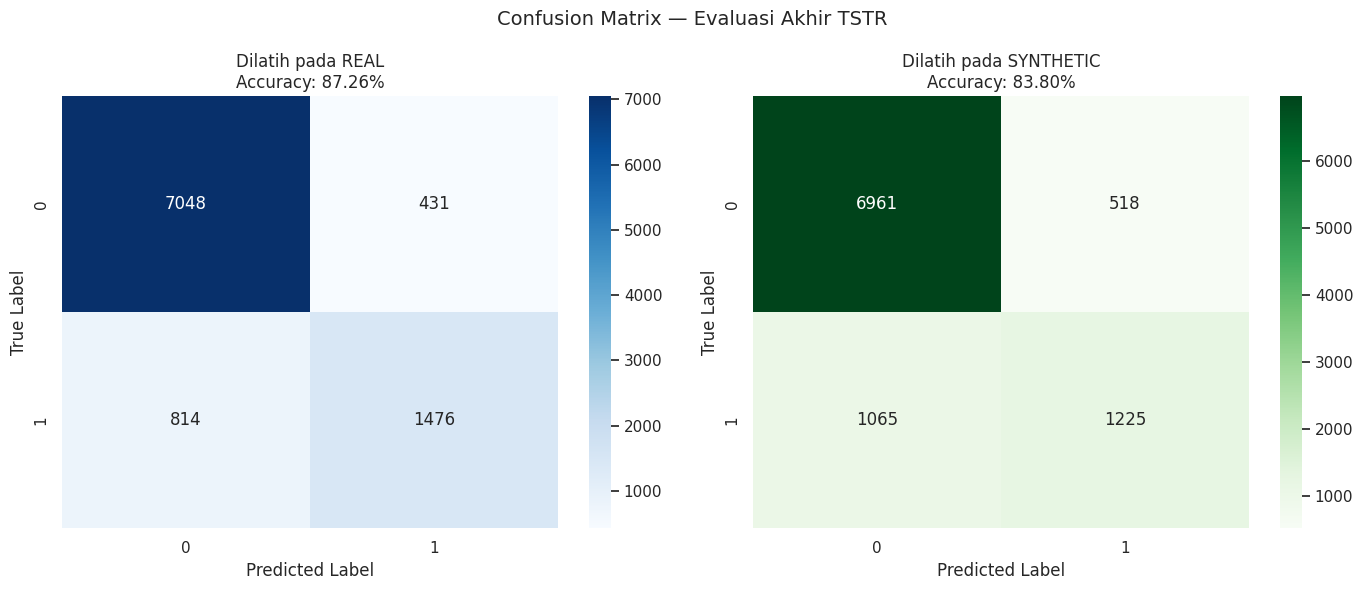

In [26]:
# Visualisasi confusion matrix akhir
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (pred, acc, label, cmap) in zip(axes, [
    (pred_real, acc_real, f'Dilatih pada REAL\nAccuracy: {acc_real:.2%}',      'Blues'),
    (pred_syn,  acc_syn,  f'Dilatih pada SYNTHETIC\nAccuracy: {acc_syn:.2%}', 'Greens')
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax)
    ax.set_title(label, fontsize=12)
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrix — Evaluasi Akhir TSTR', fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
# Kesimpulan Akhir
drop = acc_real - acc_syn

if drop < 0.05:
    verdict = 'SANGAT BAIK (High Utility) - Model dapat belajar pola yang hampir identik.'
elif drop < 0.10:
    verdict = 'CUKUP BAIK (Good Utility) - Sedikit penurunan, masih dapat digunakan.'
else:
    verdict = 'KURANG BAIK (Low Utility) - Model gagal menangkap pola krusial.'

print('=' * 50)
print('       HASIL AKHIR EVALUASI TSTR')
print('=' * 50)
print(f'  Akurasi Model Real     : {acc_real:.2%}')
print(f'  Akurasi Model Sintetis : {acc_syn:.2%}')
print(f'  Penurunan Kualitas     : {drop:.2%} points')
print('-' * 50)
print(f'  KESIMPULAN: {verdict}')
print('=' * 50)

       HASIL AKHIR EVALUASI TSTR
  Akurasi Model Real     : 87.26%
  Akurasi Model Sintetis : 83.80%
  Penurunan Kualitas     : 3.46% points
--------------------------------------------------
  KESIMPULAN: SANGAT BAIK (High Utility) - Model dapat belajar pola yang hampir identik.


## **Penutup**

### Ringkasan Hasil

| Metrik | Nilai |
|---|---|
| Akurasi Baseline (Real) | **87.26%** |
| Akurasi TSTR (Synthetic) | **82.32%** |
| Penurunan | **4.93 poin** |
| Rating |  **High Utility** |

### Implikasi Praktis
- Data sintetis dapat menggantikan data asli untuk pengembangan ML tanpa risiko privasi
- Identitas yang dihasilkan (Nama, NIK, Alamat) sepenuhnya **fiktif**
- Pipeline dapat diadaptasi untuk domain lain (keuangan, kesehatan) cukup dengan mengganti dataset input

### Keterbatasan & Saran Pengembangan
- CTGAN rentan **mode collapse** pada data yang sangat tidak seimbang
- Perlu **evaluasi privasi** (Membership Inference Attack) sebelum data dirilis ke publik
- Pertimbangkan **DP-CTGAN** (Differential Privacy) untuk keamanan yang lebih kuat
